In [1]:
#import the libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

In [2]:
#load the dataset
df=pd.read_csv('RBI_CPI.csv',skiprows=6)

In [3]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Index,Inflation (%),Unnamed: 5
0,DEC-2025,A) General Index,Provisional,198.0,1.33,NaN
1,NOV-2025,A) General Index,Final,197.9,0.71,NaN
2,OCT-2025,A) General Index,Final,197.3,0.25,NaN
3,SEP-2025,A) General Index,Final,197.0,1.44,NaN
4,AUG-2025,A) General Index,Final,197.0,2.07,NaN


In [4]:
df.tail()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Index,Inflation (%),Unnamed: 5
153,MAR-2013,A) General Index,Final,105.5,NaN,NaN
154,FEB-2013,A) General Index,Final,105.3,NaN,NaN
155,JAN-2013,A) General Index,Final,104.6,NaN,NaN
156,NaN,NaN,NaN,NaN,NaN,NaN
157,Note:\n - :CPI (Rural) for housing i...,NaN,NaN,NaN,NaN,NaN


In [5]:
df=df[['Unnamed: 0','Index']]
df.columns=['Date','CPI']

In [6]:
df.head()

,Date,CPI
0,DEC-2025,198.0
1,NOV-2025,197.9
2,OCT-2025,197.3
3,SEP-2025,197.0
4,AUG-2025,197.0


In [7]:
df.tail()

,Date,CPI
153,MAR-2013,105.5
154,FEB-2013,105.3
155,JAN-2013,104.6
156,NaN,NaN
157,Note:\n - :CPI (Rural) for housing i...,NaN


In [8]:
# Convert to datetime first (if not already)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop missing dates
df = df.dropna(subset=['Date'])

# Convert to monthly and assign first day
df['Date'] = df['Date'].dt.to_period('M').dt.to_timestamp()

# Set index
df.set_index('Date', inplace=True)

# Sort data in chronological order (oldest → latest)
df = df.sort_index()

C:\Users\pande\AppData\Local\Temp\ipykernel_10216\1637007629.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [9]:
df.head()

,CPI
Date,
2013-01-01,104.6
2013-02-01,105.3
2013-03-01,105.5
2013-04-01,106.1
2013-05-01,106.9


In [10]:
df.tail()

,CPI
Date,
2025-08-01,197.0
2025-09-01,197.0
2025-10-01,197.3
2025-11-01,197.9
2025-12-01,198.0


In [11]:
df['inflation']=df['CPI'].pct_change()*100
df=df.dropna()

In [12]:
df.head()

,CPI,inflation
Date,,
2013-02-01,105.3,0.669216
2013-03-01,105.5,0.189934
2013-04-01,106.1,0.568720
2013-05-01,106.9,0.754006
2013-06-01,109.3,2.245089


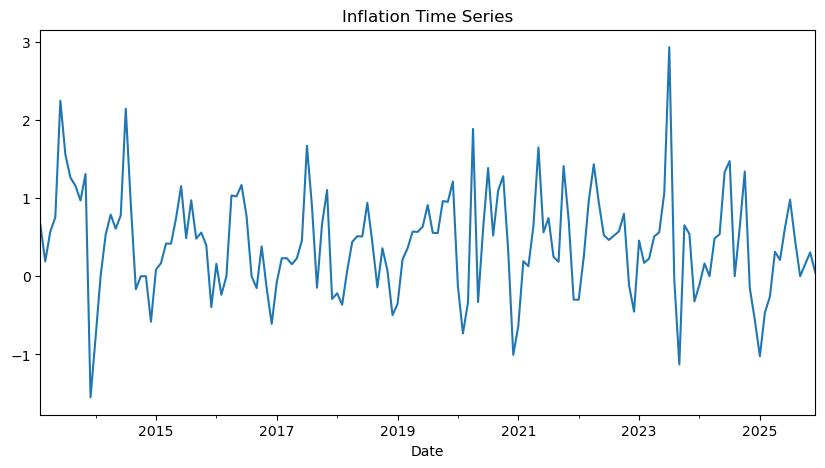

In [13]:
df['inflation'].plot(figsize=(10,5))
plt.title('Inflation Time Series')
plt.show()

In [14]:
#The inflation time series fluctuates around a stable mean with no clear long-term trend, indicating that the data is largely stationary; however, it shows occasional sharp spikes and drops, reflecting short-term volatility and shocks. Additionally, there is no clear or consistent seasonal pattern, as the fluctuations do not follow any regular or repeating cycle, suggesting that inflation movements are mainly driven by irregular factors rather than seasonality.

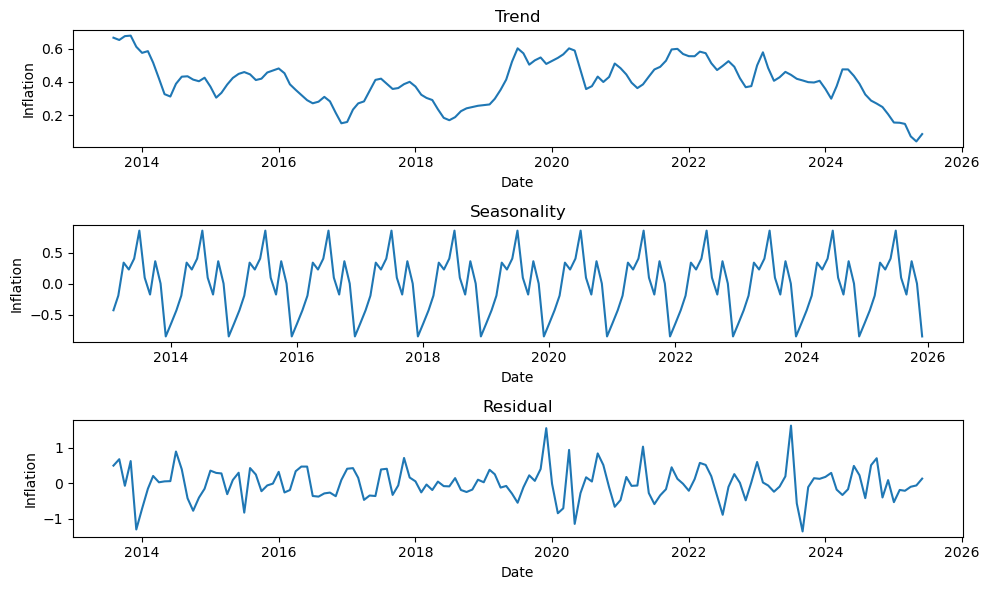

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomp = seasonal_decompose(df['inflation'], model='additive', period=12)

plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(decomp.trend)
plt.title('Trend')
plt.xlabel('Date')
plt.ylabel('Inflation')

plt.subplot(3,1,2)
plt.plot(decomp.seasonal)
plt.title('Seasonality')
plt.xlabel('Date')
plt.ylabel('Inflation')

plt.subplot(3,1,3)
plt.plot(decomp.resid)
plt.title('Residual')
plt.xlabel('Date')
plt.ylabel('Inflation')

plt.tight_layout()
plt.show()

In [16]:
#The decomposition reveals that inflation exhibits a moderate long-term trend with noticeable fluctuations over time. A strong and consistent seasonal pattern is observed, indicating regular periodic effects. The residual component appears mostly random, suggesting that the underlying structure of the series is well captured.

In [17]:
#split into train and test
x=df[['inflation']]
size=int(len(x)*0.80)
train=x.iloc[0:size].copy()
test=x.iloc[size:len(x)].copy()

In [18]:
#Fit Baseline Models

In [19]:
#Historical Mean Model
hist_mean=np.mean(df['inflation'])
hist_mean

np.float64(0.41473446076167747)

In [20]:
test.loc[:,'pred_mean']=hist_mean
test

,inflation,pred_mean
Date,,
2023-06-01,1.060860,0.414734
2023-07-01,2.928177,0.414734
2023-08-01,-0.053677,0.414734
2023-09-01,-1.127820,0.414734
2023-10-01,0.651820,0.414734
2023-11-01,0.539665,0.414734
2023-12-01,-0.322061,0.414734
2024-01-01,-0.107701,0.414734
2024-02-01,0.161725,0.414734


In [21]:
#Evaluate the error using MAPE and MAE
def mape(y_true,y_pred):
    return np.mean(np.abs((y_true-y_pred)/y_true))*100

In [22]:
mape_hist_mean=mape(test['inflation'],test['pred_mean'])
mape_hist_mean

np.float64(inf)

In [23]:
#MAPE becomes infinity because the actual value (y_true) contains zero, causing division by zero in the MAPE formula.

In [24]:
#Use MAE instead
from sklearn.metrics import mean_absolute_error
mae_hist_mean=mean_absolute_error(test['inflation'],test['pred_mean'])
mae_hist_mean

0.580039542017166

In [25]:
#On average, the model’s predictions deviate from the actual inflation by about 0.58 units, indicating the typical magnitude of error.

In [26]:
#  Naive Model:Last observation (from train set)
last_value = train['inflation'].iloc[-1]
last_value

np.float64(0.5614823133071267)

In [27]:
# Assign this value as prediction for all test points
test['pred_last'] = last_value
test

,inflation,pred_mean,pred_last
Date,,,
2023-06-01,1.060860,0.414734,0.561482
2023-07-01,2.928177,0.414734,0.561482
2023-08-01,-0.053677,0.414734,0.561482
2023-09-01,-1.127820,0.414734,0.561482
2023-10-01,0.651820,0.414734,0.561482
2023-11-01,0.539665,0.414734,0.561482
2023-12-01,-0.322061,0.414734,0.561482
2024-01-01,-0.107701,0.414734,0.561482
2024-02-01,0.161725,0.414734,0.561482


In [28]:
mape_last=mape(test['inflation'],test['pred_last'])
mape_last

np.float64(inf)

In [29]:
#Use MAE instead
from sklearn.metrics import mean_absolute_error
mae_last=mean_absolute_error(test['inflation'],test['pred_last'])
mae_last

0.6183733163979674

In [30]:
#The historical mean model performs better than the naive model because it uses the overall average of the data, which reduces the effect of short-term fluctuations. In contrast, the naive model depends only on the last value, which can be affected by sudden changes, leading to higher error.

In [31]:
#check for stationarity:
r=adfuller(df['inflation'])
r

(np.float64(-8.350341819721873),
 np.float64(3.006571955003791e-13),
 6,
 148,
 {'1%': np.float64(-3.4753253063120644),
  '5%': np.float64(-2.881274703275226),
  '10%': np.float64(-2.5772928360116873)},
 np.float64(226.62874416668677))

In [32]:
#since, the p-value is less than 0.05, the series is stationary.

In [33]:
#Therefore, no differencing is needed. Hence d=0.

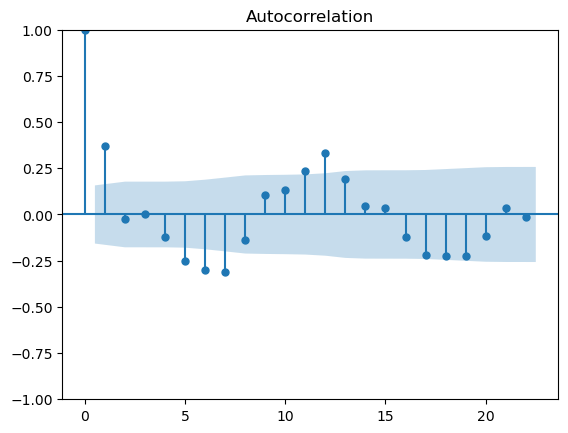

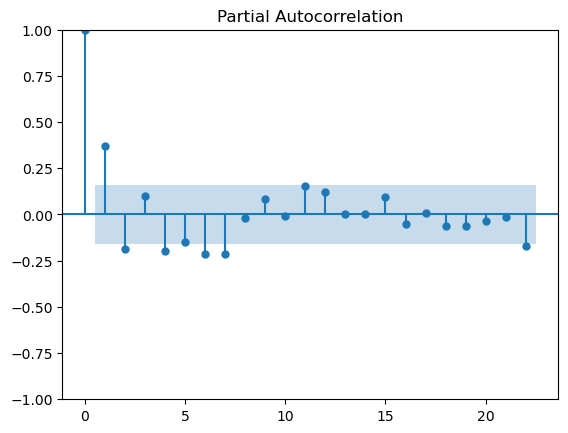

In [34]:
#check the lag order
plot_acf(df['inflation'])
plt.show()

plot_pacf(df['inflation'])
plt.show()

In [ ]:
#Although the ACF and PACF plots suggest a lower-order model such as (1,0,1), additional significant lags indicate that higher-order terms may be relevant. Therefore, the (2,0,2) specification is adopted to better capture the underlying dynamics of the inflation series.

In [35]:
#ARIMA Model Fitting
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")
model=ARIMA(df['inflation'],order=(2,0,2))
model_fit=model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              inflation   No. Observations:                  155
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -140.553
Date:                Tue, 07 Apr 2026   AIC                            293.105
Time:                        20:33:39   BIC                            311.366
Sample:                    02-01-2013   HQIC                           300.522
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4153      0.078      5.320      0.000       0.262       0.568
ar.L1          0.2320    237.907      0.001      0.999    -466.058     466.522
ar.L2          0.0392     27.329      0.001      0.9

In [36]:
#Constant (0.4153): The average level of inflation is around 0.415, showing a positive baseline in the series.
#AR(1) (0.2320): A 1-period past value has a small positive effect (0.232) on current inflation, but it is statistically insignificant (p = 0.999).
#AR(2) (0.0392): The 2-period lag has an almost negligible impact (0.039) and is not significant (p = 0.999), meaning weak dependence.
#MA(1) (0.2437): The first lag of past error has a small positive effect (0.244), but it is statistically insignificant (p = 0.999).
#MA(2) (-0.2044): The second lag of error has a small negative effect (-0.204), but again not significant (p = 0.999).
#Sigma² (0.3583): The variance of the residuals is 0.358, indicating moderate volatility in the unexplained part of the model.

#The ARIMA(2,0,2) model is not well-fitted for this data, as most of the coefficients are statistically insignificant (very high p-values), indicating that past values and past errors do not meaningfully explain current inflation. This suggests that the model fails to capture the underlying dynamics of the series, which is why it produces flat or weak forecasts despite having a relatively acceptable error measure.

In [37]:
#Split data 
train = df['inflation'][:int(len(df)*0.8)]
test = df['inflation'][int(len(df)*0.8):]

#Fit ARIMA model (use your best order)
model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

#Forecast next 12 steps
forecast = model_fit.forecast(steps=len(test))

#Create comparison DataFrame
comparison = pd.DataFrame({
    'Actual': test,
    'Predicted': forecast
})

print(comparison)

              Actual  Predicted
2023-06-01  1.060860   0.455207
2023-07-01  2.928177   0.450840
2023-08-01 -0.053677   0.427588
2023-09-01 -1.127820   0.447655
2023-10-01  0.651820   0.428644
2023-11-01  0.539665   0.446532
2023-12-01 -0.322061   0.429692
2024-01-01 -0.107701   0.445545
2024-02-01  0.161725   0.430622
2024-03-01  0.000000   0.444669
2024-04-01  0.484392   0.431446
2024-05-01  0.535619   0.443894
2024-06-01  1.331913   0.432176
2024-07-01  1.472135   0.443207
2024-08-01  0.000000   0.432823
2024-09-01  0.621762   0.442598
2024-10-01  1.338826   0.433396
2024-11-01 -0.152439   0.442058
2024-12-01 -0.559796   0.433904
2025-01-01 -1.023541   0.441580
2025-02-01 -0.465357   0.434354
2025-03-01 -0.259740   0.441156
2025-04-01  0.312500   0.434753
2025-05-01  0.207684   0.440781
2025-06-01  0.621762   0.435106
2025-07-01  0.978373   0.440448
2025-08-01  0.458950   0.435420
2025-09-01  0.000000   0.440153
2025-10-01  0.152284   0.435697
2025-11-01  0.304105   0.439892
2025-12-

In [38]:
mae_arima=mean_absolute_error(test,forecast)
mae_arima

0.5828227578291071

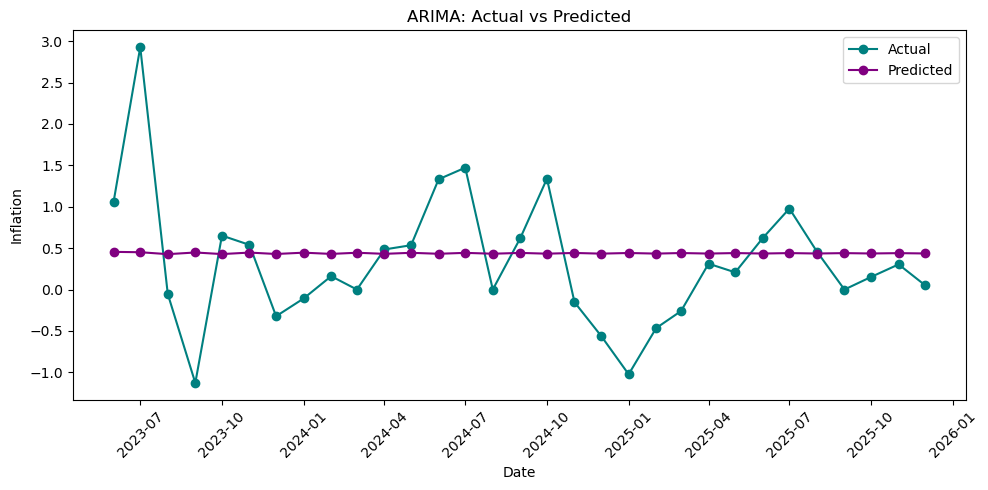

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test.index, test, label='Actual', marker='o',color='teal')
plt.plot(forecast.index, forecast, label='Predicted', marker='o',color='purple')

plt.title('ARIMA: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Inflation')

plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

In [40]:
#The ARIMA model produces nearly flat forecasts around the mean, failing to capture the sharp fluctuations and volatility present in the actual inflation values. This indicates that the model has weak predictive power for this dataset and does not effectively represent the underlying dynamics of inflation.

In [ ]:
#Since the data shows a clear seasonal pattern from decomposition, a simple ARIMA model may not be sufficient.
#Hence, a SARIMA model is used to better account for both trend and seasonality in the inflation series.

In [41]:
#Fit SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(train,
                       order=(2,0,2),
                       seasonal_order=(1,0,1,12))

sarima_result = sarima_model.fit()

In [42]:
forecast_sarima = sarima_result.forecast(steps=len(test))

In [43]:
import pandas as pd

comparison_sarima = pd.DataFrame({
    'Actual': test,
    'Predicted': forecast_sarima
})

print(comparison_sarima)

              Actual  Predicted
2023-06-01  1.060860   0.803544
2023-07-01  2.928177   0.997221
2023-08-01 -0.053677   0.595428
2023-09-01 -1.127820   0.355398
2023-10-01  0.651820   0.697833
2023-11-01  0.539665   0.450931
2023-12-01 -0.322061  -0.323532
2024-01-01 -0.107701  -0.079508
2024-02-01  0.161725   0.094095
2024-03-01  0.000000   0.272271
2024-04-01  0.484392   0.721983
2024-05-01  0.535619   0.626095
2024-06-01  1.331913   0.787815
2024-07-01  1.472135   0.996944
2024-08-01  0.000000   0.593030
2024-09-01  0.621762   0.353861
2024-10-01  1.338826   0.695692
2024-11-01 -0.152439   0.449196
2024-12-01 -0.559796  -0.324063
2025-01-01 -1.023541  -0.080407
2025-02-01 -0.465357   0.092936
2025-03-01 -0.259740   0.270845
2025-04-01  0.312500   0.719871
2025-05-01  0.207684   0.624139
2025-06-01  0.621762   0.785618
2025-07-01  0.978373   0.994432
2025-08-01  0.458950   0.591151
2025-09-01  0.000000   0.352361
2025-10-01  0.152284   0.693671
2025-11-01  0.304105   0.447565
2025-12-

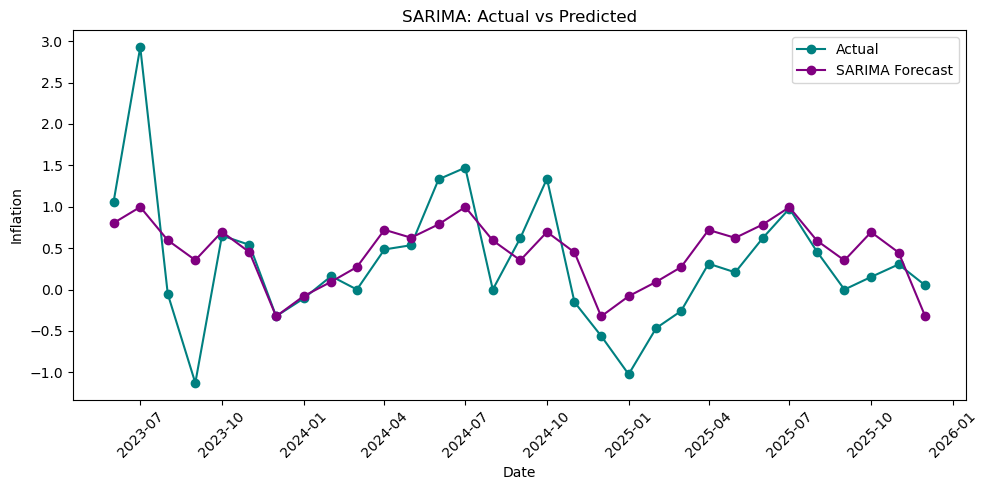

In [44]:
plt.figure(figsize=(10,5))

plt.plot(comparison_sarima.index, comparison_sarima['Actual'],
         label='Actual', marker='o',color='teal')

plt.plot(comparison_sarima.index, comparison_sarima['Predicted'],
         label='SARIMA Forecast', marker='o',color='purple')

plt.title('SARIMA: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Inflation')

plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

In [45]:
#The SARIMA model successfully captures the seasonal pattern in inflation and follows the general trend of the actual series. However, the predictions are smoother and fail to fully capture sudden spikes and sharp fluctuations, leading to moderate forecasting errors.

In [46]:
from sklearn.metrics import mean_absolute_error

mae_sarima = mean_absolute_error(test, forecast_sarima)
mae_sarima

0.42238314710466973

In [ ]:
#The mean absolute error of 0.422 indicates that, on average, the SARIMA model’s predictions deviate from the actual inflation values by about 0.422 units, suggesting a fairly good level of forecasting accuracy.

In [47]:
#Walk Forward Validation:
#Initialize history
history = list(train)   # start with training data
predictions = []

#Walk-forward loop
for t in range(len(test)):
    
    # Fit model on current history
    model = ARIMA(history, order=(2,0,2))   # use your best order
    model_fit = model.fit()
    
    # Forecast next step
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    
    # Add actual observation to history
    history.append(test.iloc[t])


#Convert predictions to Series
predictions_series = pd.Series(predictions, index=test.index)

#Actual vs Predicted table
comparison = pd.DataFrame({
    'Actual': test,
    'Predicted': predictions_series
})

print("Actual vs Predicted (Walk-forward):")
print(comparison)

Actual vs Predicted (Walk-forward):
              Actual  Predicted
Date                           
2023-06-01  1.060860   0.455207
2023-07-01  2.928177   0.751778
2023-08-01 -0.053677   1.594747
2023-09-01 -1.127820  -0.187973
2023-10-01  0.651820  -0.175379
2023-11-01  0.539665   0.707051
2023-12-01 -0.322061   0.296587
2024-01-01 -0.107701   0.130304
2024-02-01  0.161725   0.397426
2024-03-01  0.000000   0.433050
2024-04-01  0.484392   0.358967
2024-05-01  0.535619   0.636565
2024-06-01  1.331913   0.494635
2024-07-01  1.472135   0.875750
2024-08-01  0.000000   0.635032
2024-09-01  0.621762   0.000512
2024-10-01  1.338826   0.648502
2024-11-01 -0.152439   0.601022
2024-12-01 -0.559796  -0.090668
2025-01-01 -1.023541   0.205719
2025-02-01 -0.465357  -0.031268
2025-03-01 -0.259740   0.491973
2025-04-01  0.312500   0.128827
2025-05-01  0.207684   0.528637
2025-06-01  0.621762   0.247514
2025-07-01  0.978373   0.612786
2025-08-01  0.458950   0.572125
2025-09-01  0.000000   0.363493
2025

In [48]:
#Error calculation
mae_wf = mean_absolute_error(test, predictions_series)
mae_wf

0.5704628326512228

In [ ]:
#The mean absolute error of 0.57 in the walk-forward validation indicates that, on average, the model’s predictions differ from the actual inflation values by about 0.57 units, reflecting a moderate level of forecasting accuracy.

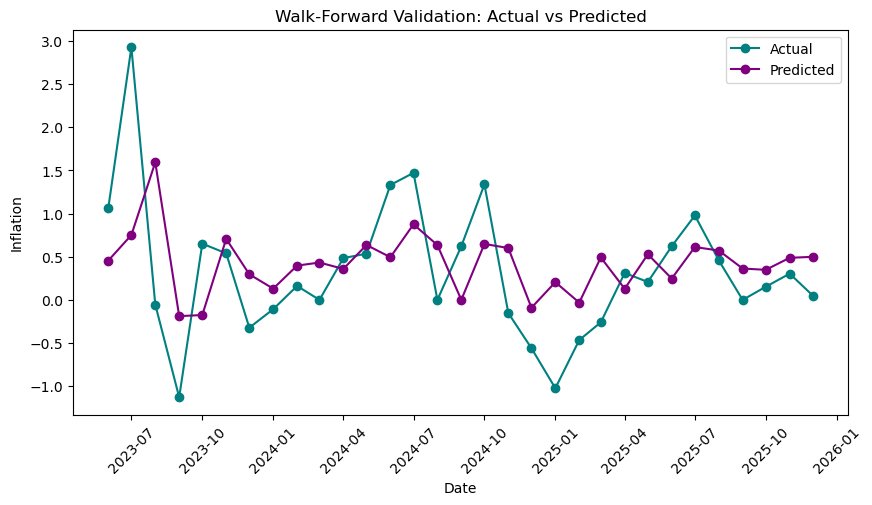

In [49]:
#Plot results
plt.figure(figsize=(10,5))
plt.plot(test, label='Actual', marker='o',color='teal')
plt.plot(predictions_series, label='Predicted', marker='o',color='purple')
plt.title('Walk-Forward Validation: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Inflation')

plt.xticks(rotation=45)

plt.legend()
plt.show()

In [50]:
#The walk-forward validation results show that the model is able to follow the general movement of inflation over time by updating itself with new observations at each step. The predicted values closely track the overall trend of the actual data, although some deviations are observed during sharp fluctuations. This indicates that the model adapts well to recent changes and provides more responsive and realistic forecasts compared to static models.

In [51]:
#Sliding Window Approach
#Set window size

window_size = 50   

history = list(train[-window_size:])   # last 50 observations
predictions = []

#Sliding window loop
for t in range(len(test)):
    
    model = ARIMA(history, order=(2,0,2))   # use your best model
    model_fit = model.fit()
    
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    
    # move window forward
    history.append(test.iloc[t])
    history.pop(0)

#Create comparison table
comparison = pd.DataFrame({
    'Actual': test.values,
    'Predicted': predictions
}, index=test.index)

print(comparison)

              Actual  Predicted
Date                           
2023-06-01  1.060860   0.951504
2023-07-01  2.928177   0.929246
2023-08-01 -0.053677   0.700395
2023-09-01 -1.127820  -0.518197
2023-10-01  0.651820  -0.175383
2023-11-01  0.539665   0.713339
2023-12-01 -0.322061   0.344614
2024-01-01 -0.107701   0.399526
2024-02-01  0.161725   0.806385
2024-03-01  0.000000   0.764932
2024-04-01  0.484392   0.932917
2024-05-01  0.535619   0.931943
2024-06-01  1.331913   0.789982
2024-07-01  1.472135   1.145032
2024-08-01  0.000000   0.588745
2024-09-01  0.621762   0.044306
2024-10-01  1.338826   0.806955
2024-11-01 -0.152439   0.453182
2024-12-01 -0.559796  -0.157927
2025-01-01 -1.023541   0.402567
2025-02-01 -0.465357   0.140042
2025-03-01 -0.259740   1.028346
2025-04-01  0.312500   0.435393
2025-05-01  0.207684   1.028296
2025-06-01  0.621762   0.406868
2025-07-01  0.978373   0.993211
2025-08-01  0.458950   0.755397
2025-09-01  0.000000   0.536692
2025-10-01  0.152284   0.397789
2025-11-

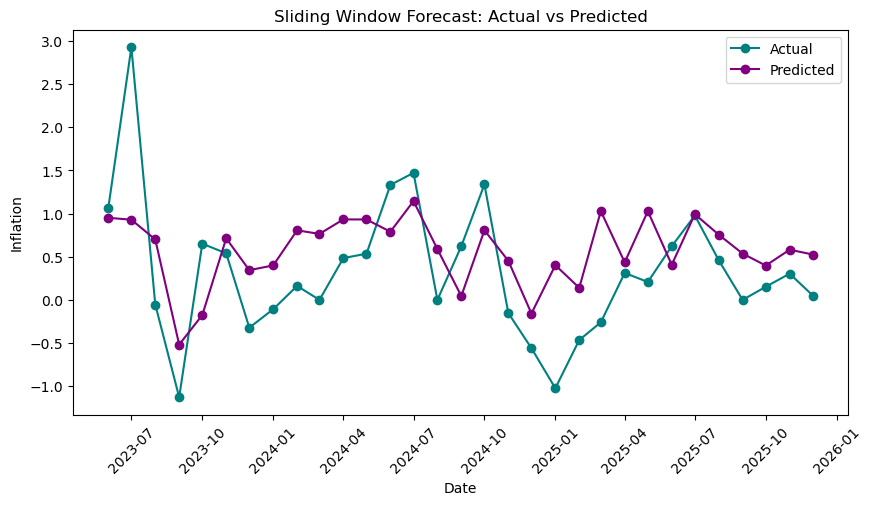

In [52]:
#Plot Actual vs Predicted
plt.figure(figsize=(10,5))
plt.plot(comparison['Actual'], label='Actual', marker='o',color='teal')
plt.plot(comparison['Predicted'], label='Predicted', marker='o',color='purple')
plt.title("Sliding Window Forecast: Actual vs Predicted")
plt.xlabel('Date')
plt.ylabel('Inflation')

plt.xticks(rotation=45)

plt.legend()
plt.show()

In [53]:
#The sliding window model shows moderate responsiveness to recent data and tracks the direction of inflation better than ARIMA, but it still smooths out extreme fluctuations and misses major peaks and troughs.

In [54]:
#Final Take:
#Both walk-forward and sliding window approaches show clear improvement over ARIMA by adapting to recent data and capturing overall trends better, but they still struggle with sharp volatility, indicating partial improvement rather than a perfect fit.

In [55]:
mae_sw = mean_absolute_error(comparison['Actual'], comparison['Predicted'])
mae_sw

0.5742115682237805

In [ ]:
#The mean absolute error of 0.57 in the sliding window model  indicates that, on average, the model’s predictions differ from the actual inflation values by about 0.57 units, reflecting a moderate level of forecasting accuracy.

In [56]:
print("Historical Mean MAE:", mae_hist_mean)
print("Last Value MAE:", mae_last)
print("ARIMA MAE:", mae_arima)
print("Walk-forward MAE:", mae_wf)
print("Sliding Window MAE:", mae_sw)

Historical Mean MAE: 0.580039542017166
Last Value MAE: 0.6183733163979674
ARIMA MAE: 0.5828227578291071
Walk-forward MAE: 0.5704628326512228
Sliding Window MAE: 0.5742115682237805


In [58]:
df.columns

Index(['CPI', 'inflation'], dtype='object')

In [59]:
#Although the SARIMA model captures seasonal patterns and provides a reasonable fit, it does not fully account for short-term fluctuations in inflation. Therefore, a SARIMAX model with lagged inflation is employed to incorporate recent past values as additional inputs. This allows the model to better capture dynamic changes and improves its ability to reflect real-world inflation movements more accurately.

In [60]:
##Lagged SARIMAX:
#create lag features(past values of inflation)
df['lag1'] = df['inflation'].shift(1)#previous months's inflation
df['lag2'] = df['inflation'].shift(2)#2 months back inflation

# Drop missing values created due to shifting
df = df.dropna()

In [61]:
#split into 80% training data
train_size = int(len(df) * 0.8)

#create train and test datasets
train = df.iloc[:train_size]
test = df.iloc[train_size:]

#define target variable(what we want to predict)
y_train = train['inflation']
y_test = test['inflation']

#define exogenous variables(lagged inflation as predictors)
X_train = train[['lag1', 'lag2']]
X_test = test[['lag1', 'lag2']]

In [62]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(y_train,
                exog=X_train,
                order=(1,0,1),#ARIMA part(captures short term pattern)
                seasonal_order=(1,0,1,12))#seasonal pattern(monthly cycle)

model_fit = model.fit()

In [63]:
#forecast for test period using exogenous inputs
forecast = model_fit.forecast(steps=len(y_test), exog=X_test)

In [64]:
import pandas as pd

#combine actual and predicted values for comparison
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': forecast
})

print(comparison)

              Actual  Predicted
2023-06-01  1.060860   0.798755
2023-07-01  2.928177   1.084474
2023-08-01 -0.053677   1.034933
2023-09-01 -1.127820  -0.169956
2023-10-01  0.651820   0.401999
2023-11-01  0.539665   0.651062
2023-12-01 -0.322061  -0.363974
2024-01-01 -0.107701  -0.158981
2024-02-01  0.161725  -0.003948
2024-03-01  0.000000   0.279612
2024-04-01  0.484392   0.628544
2024-05-01  0.535619   0.587428
2024-06-01  1.331913   0.797069
2024-07-01  1.472135   1.161258
2024-08-01  0.000000   0.603745
2024-09-01  0.621762   0.087034
2024-10-01  1.338826   0.857410
2024-11-01 -0.152439   0.542277
2024-12-01 -0.559796  -0.661480
2025-01-01 -1.023541  -0.106745
2025-02-01 -0.465357  -0.207407
2025-03-01 -0.259740   0.265428
2025-04-01  0.312500   0.663373
2025-05-01  0.207684   0.584610
2025-06-01  0.621762   0.737909
2025-07-01  0.978373   1.026419
2025-08-01  0.458950   0.590440
2025-09-01  0.000000   0.290771
2025-10-01  0.152284   0.615239
2025-11-01  0.304105   0.330442
2025-12-

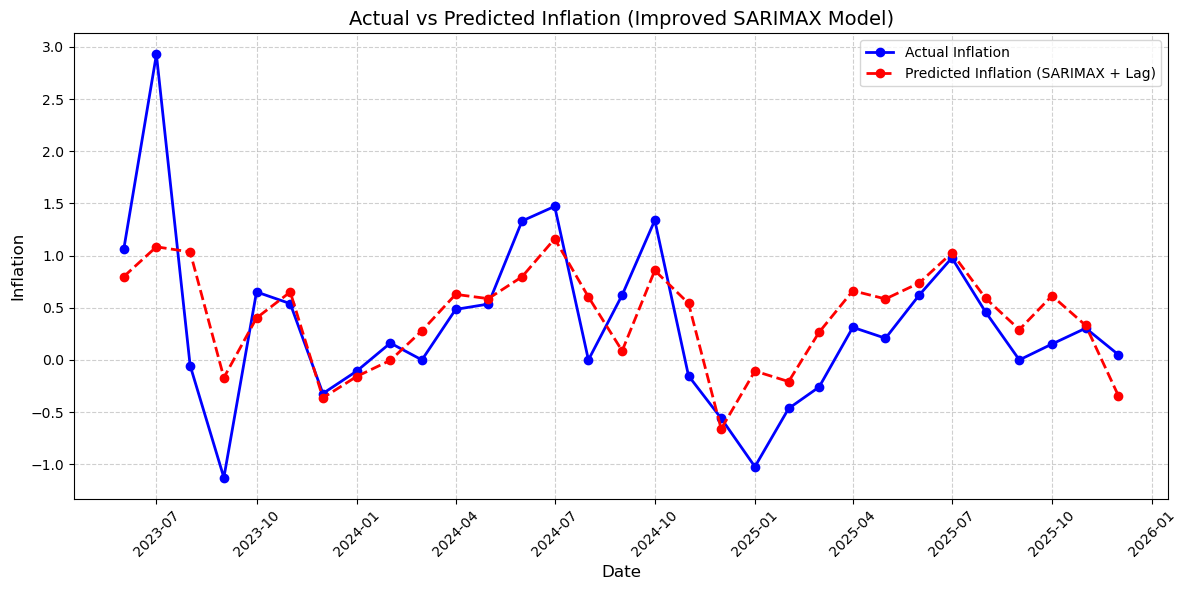

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

# Plot actual values
plt.plot(y_test.index, y_test, 
         label='Actual Inflation', 
         color='blue', 
         linewidth=2, marker='o')

# Plot predicted values
plt.plot(y_test.index, forecast, 
         label='Predicted Inflation (SARIMAX + Lag)', 
         color='red', 
         linestyle='--', linewidth=2, marker='o')

# Add title and labels
plt.title('Actual vs Predicted Inflation (Improved SARIMAX Model)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Inflation', fontsize=12)

# Add grid for clarity
plt.grid(True, linestyle='--', alpha=0.6)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Add legend
plt.legend()

# Tight layout for neatness
plt.tight_layout()

# Show plot
plt.show()

In [66]:
#The predicted values closely follow the actual inflation, showing that the model captures both trend and short-term changes effectively. Although some extreme spikes are slightly smoothed, the overall fit is much improved and realistic.

#The observed inflation trend reflects real-world economic conditions in India, where sharp fluctuations in 2023 were driven by food price shocks and supply disruptions, followed by moderated inflation in 2024 due to tight monetary policy and improved supply. The decline in late 2024–early 2025 can be attributed to base effects and better agricultural output, while the subsequent rise in 2025 reflects demand recovery and seasonal factors. Overall, inflation dynamics are primarily influenced by food prices, policy actions, and global cost pressures.

#Final Take:
#Inflation in India is more shock-driven than trend-driven.

In [67]:
mae_inf = mean_absolute_error(y_test, forecast)
mae_inf

0.4002024135046985

In [ ]:
#The mean absolute error of 0.40 indicates that, on average, the SARIMAX model with lagged inflation predicts values within about 0.40 units of the actual inflation, reflecting a strong level of forecasting accuracy.

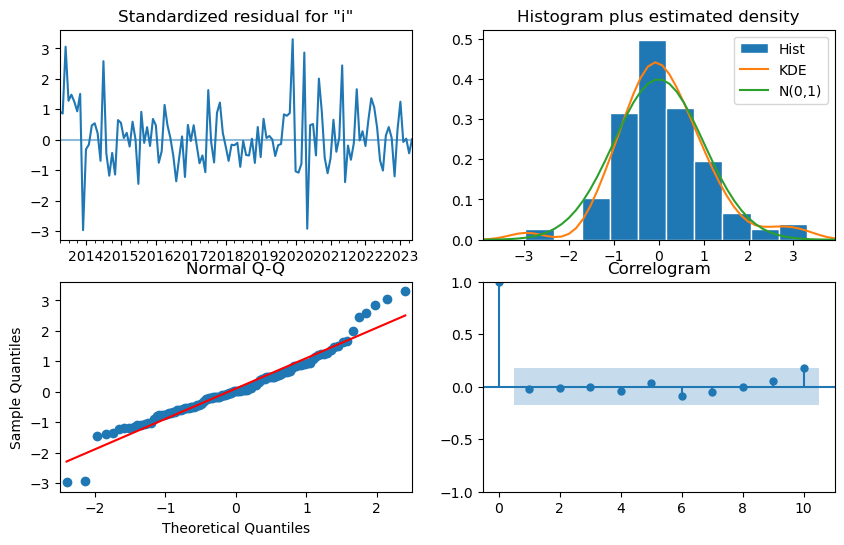

In [68]:
model_fit.plot_diagnostics(figsize=(10,6))
plt.show()

In [69]:
#The diagnostic plots indicate that the residuals behave like white noise, suggesting that the model adequately captures the underlying pattern in the data.

In [70]:
print("Historical Mean MAE:", mae_hist_mean)
print("Last Value MAE:", mae_last)
print("ARIMA MAE:", mae_arima)
print("Walk-forward MAE:", mae_wf)
print("SARIMA MAE:", mae_sarima)
print("Sliding Window MAE:", mae_sw)
print("SARIMAX With Lagged Inflation:",mae_inf)

Historical Mean MAE: 0.580039542017166
Last Value MAE: 0.6183733163979674
ARIMA MAE: 0.5828227578291071
Walk-forward MAE: 0.5704628326512228
SARIMA MAE: 0.42238314710466973
Sliding Window MAE: 0.5742115682237805
SARIMAX With Lagged Inflation: 0.4002024135046985


In [71]:
#A comparison of forecasting errors across all models shows that the SARIMAX model with lagged inflation achieves the lowest mean absolute error (0.4002), outperforming traditional approaches such as ARIMA, SARIMA, and baseline methods. While models like SARIMA successfully capture seasonality, they tend to smooth out short-term fluctuations, limiting their responsiveness to recent changes. By incorporating lagged inflation, the SARIMAX model effectively integrates both seasonal structure and recent dynamics, resulting in more precise and realistic forecasts. Therefore, SARIMAX with lagged inflation emerges as the most reliable and robust model for inflation forecasting in this analysis.

In [73]:
##Conclusion:
#This project evaluates inflation forecasting using models ranging from baseline approaches to ARIMA, SARIMA, and finally SARIMAX with lagged inflation. While ARIMA and SARIMA capture trend and seasonality, they smooth out short-term fluctuations. The SARIMAX model with lagged inflation achieves the lowest error and most closely tracks actual values, making it the most reliable model in this analysis.
#Inflation movements reflect real economic developments. The sharp fluctuations during 2020–2021 are driven by COVID-19 disruptions, while the rise in 2022 is linked to global fuel and commodity shocks due to the Russia–Ukraine conflict. In 2023, inflation stabilizes with policy control and supply recovery, though food price volatility causes spikes. In 2024, inflation remains moderate with seasonal and demand-supply fluctuations, while 2025 shows controlled yet dynamic inflation due to strengthening demand. By 2026, inflation appears relatively stable with minor variations as economic conditions balance.
#By incorporating lagged inflation, the SARIMAX model captures both structural patterns and short-term changes, producing forecasts that are both accurate and economically meaningful. Overall, combining recent information with seasonality significantly improves forecasting performance, making SARIMAX with lagged inflation a robust and practical model for inflation prediction.